## 2. Dataset Loading

This step loads the smart manufacturing dataset from CSV into a Pandas DataFrame.


In [1]:
import pandas as pd

df = pd.read_csv("smart_manufacturing_ml_dataset.csv")

df.head()

,machine_id,plant,production_line,machine_type,shift,operator_experience_years,machine_age_years,ambient_temperature_c,humidity_pct,vibration_mm_s,...,bearing_temperature_c,load_percent,noise_db,material_grade,lubricant_type,supplier_tier,inspection_status,batch_size,machine_energy_kwh,maintenance_risk
0,118835,Chennai,L3,CNC,Afternoon,9.80,12.55,29.25,98.00,3.116,...,44.25,76.29,74.60,HighStrength,Synthetic,NaN,Rework,344,39.19,Medium
1,100736,Hyderabad,L1,Milling,Afternoon,0.20,9.14,27.87,63.55,2.284,...,50.44,73.22,69.54,Standard,Synthetic,Local,Pass,382,40.39,Low
2,120211,Ahmedabad,L1,Lathe,Night,9.68,3.82,27.89,57.28,2.662,...,46.10,80.38,75.77,Standard,Synthetic,Local,Pass,297,47.36,Low
3,118587,Chennai,L5,Robot,Afternoon,10.70,7.11,22.20,68.56,1.457,...,42.14,71.95,70.10,Recycled,Bio,Tier3,Pass,773,58.99,Medium
4,105358,Pune,L1,Compressor,Morning,5.13,2.73,31.78,79.86,2.873,...,55.14,58.85,70.34,Recycled,Mineral,Tier2,Pass,984,39.78,High


# Smart Manufacturing Machine Learning Project

## Review 1

This project analyzes a smart manufacturing dataset containing machine,
environmental, production, maintenance, and operational information.

Two machine learning tasks are performed:

1. Regression — Predict machine energy consumption (`machine_energy_kwh`)
2. Classification — Predict maintenance risk (`maintenance_risk`)

The project covers:
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Missing Value Treatment
- Duplicate Detection
- Outlier Detection
- Feature Engineering
- Categorical Encoding
- Feature Scaling
- Regression
- Classification
- Model Evaluation
- Hyperparameter Tuning
- Cross-Validation

In [2]:
# ================================
# 1. IMPORTS & CONFIGURATION
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OrdinalEncoder,
    PolynomialFeatures
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import (
    SVR,
    SVC
)

from sklearn.neighbors import (
    KNeighborsRegressor,
    KNeighborsClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset Loading

The dataset is loaded into a pandas DataFrame for further analysis.

The regression target is `machine_energy_kwh`, representing machine
energy consumption.

The classification target is `maintenance_risk`, representing the
maintenance risk category of each machine.

In [3]:
# Load dataset

df = pd.read_csv("smart_manufacturing_ml_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 2.1 Previewing Raw Data

This step previews the first five rows of the dataset to inspect feature columns and sample values.


In [4]:
df.head()

,machine_id,plant,production_line,machine_type,shift,operator_experience_years,machine_age_years,ambient_temperature_c,humidity_pct,vibration_mm_s,hydraulic_pressure_bar,motor_current_a,rpm,production_rate_units_hr,defect_rate_pct,downtime_hours_30d,maintenance_count,days_since_maintenance,power_factor,oil_temperature_c,bearing_temperature_c,load_percent,noise_db,material_grade,lubricant_type,supplier_tier,inspection_status,batch_size,machine_energy_kwh,maintenance_risk
0,118835,Chennai,L3,CNC,Afternoon,9.80,12.55,29.25,98.00,3.116,6.53,19.64,2335.8,112.9,2.625,3.48,3,19.7,0.953,51.09,44.25,76.29,74.60,HighStrength,Synthetic,NaN,Rework,344,39.19,Medium
1,100736,Hyderabad,L1,Milling,Afternoon,0.20,9.14,27.87,63.55,2.284,7.81,30.47,2477.5,107.2,1.382,0.81,1,31.0,0.879,60.54,50.44,73.22,69.54,Standard,Synthetic,Local,Pass,382,40.39,Low
2,120211,Ahmedabad,L1,Lathe,Night,9.68,3.82,27.89,57.28,2.662,7.27,32.25,3558.0,146.4,7.156,0.44,1,10.3,0.942,48.81,46.10,80.38,75.77,Standard,Synthetic,Local,Pass,297,47.36,Low
3,118587,Chennai,L5,Robot,Afternoon,10.70,7.11,22.20,68.56,1.457,7.64,38.33,3419.4,94.6,7.787,1.02,1,130.7,0.903,55.07,42.14,71.95,70.10,Recycled,Bio,Tier3,Pass,773,58.99,Medium
4,105358,Pune,L1,Compressor,Morning,5.13,2.73,31.78,79.86,2.873,8.63,30.06,2456.5,78.3,9.551,0.24,1,75.6,0.912,NaN,55.14,58.85,70.34,Recycled,Mineral,Tier2,Pass,984,39.78,High


### 2.2 Dataset Shape & Row Count

This step checks the total number of observations (rows) present in the dataset.


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 22260
Number of columns: 30


### 2.3 Feature Data Types Inspection

This step inspects the data type of each column and summarizes the counts of numerical vs categorical attributes.


In [6]:
df.dtypes

machine_id                     int64
plant                         object
production_line               object
machine_type                  object
shift                         object
operator_experience_years    float64
machine_age_years            float64
ambient_temperature_c        float64
humidity_pct                 float64
vibration_mm_s               float64
hydraulic_pressure_bar       float64
motor_current_a              float64
rpm                          float64
production_rate_units_hr     float64
defect_rate_pct              float64
downtime_hours_30d           float64
maintenance_count              int64
days_since_maintenance       float64
power_factor                 float64
oil_temperature_c            float64
bearing_temperature_c        float64
load_percent                 float64
noise_db                     float64
material_grade                object
lubricant_type                object
supplier_tier                 object
inspection_status             object
b

### 2.3 Feature Data Types Inspection

This step inspects the data type of each column and summarizes the counts of numerical vs categorical attributes.


In [7]:
df.dtypes.value_counts()

float64    18
object      9
int64       3
Name: count, dtype: int64

### 2.4 Initial Missing Values Check

This step computes the total number of missing values for each attribute in the raw dataset.


In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

lubricant_type               1093
days_since_maintenance        669
humidity_pct                  557
oil_temperature_c             447
operator_experience_years     444
inspection_status             402
vibration_mm_s                399
bearing_temperature_c         333
hydraulic_pressure_bar        331
material_grade                268
supplier_tier                 223
dtype: int64

In [9]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
lubricant_type,1093,4.91
days_since_maintenance,669,3.01
humidity_pct,557,2.50
oil_temperature_c,447,2.01
operator_experience_years,444,1.99
inspection_status,402,1.81
vibration_mm_s,399,1.79
bearing_temperature_c,333,1.50
hydraulic_pressure_bar,331,1.49
material_grade,268,1.20


### 2.5 Initial Duplicate Check

This step checks for identical duplicate rows across the raw dataset.


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 260


### 2.6 Numerical Feature Descriptive Statistics

This step generates summary statistics including mean, standard deviation, min, max, and quantiles for all numerical features.


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
machine_id,22260.0,110999.023001,6351.648929,100001.000,105502.75000,110997.500,116500.2500,122000.000000
operator_experience_years,21816.0,6.475534,3.147727,0.200,4.26000,6.430,8.6200,20.000000
machine_age_years,22260.0,6.381268,3.536081,0.200,3.75750,5.740,8.3300,18.000000
ambient_temperature_c,22260.0,28.998906,4.498104,12.020,25.98000,29.020,32.0500,50.060000
humidity_pct,21703.0,62.135863,14.869514,20.000,51.95000,62.100,72.4100,98.000000
vibration_mm_s,21861.0,2.538027,2.182686,0.207,1.59900,2.213,3.0400,68.854809
hydraulic_pressure_bar,21929.0,7.399726,1.096907,3.000,6.66000,7.400,8.1400,11.650000
motor_current_a,22260.0,31.151957,8.341988,8.000,25.69750,31.180,36.4425,108.516390
rpm,22260.0,2800.749470,550.226441,900.000,2427.40000,2795.350,3171.0250,4500.000000
production_rate_units_hr,22260.0,118.210790,30.285837,25.000,97.80000,118.000,138.2000,288.491168


### 2.7 Classification Target Class Counts

This step examines the frequency and percentage distribution of categories in the maintenance_risk target.


In [12]:
print(df["maintenance_risk"].value_counts())

maintenance_risk
Low       9958
Medium    8125
High      4177
Name: count, dtype: int64


### 2.7 Classification Target Class Counts

This step examines the frequency and percentage distribution of categories in the maintenance_risk target.


In [13]:
print(df["maintenance_risk"].value_counts(normalize=True).mul(100).round(2))

maintenance_risk
Low       44.73
Medium    36.50
High      18.76
Name: proportion, dtype: float64


### 2.8 Regression Target Summary Statistics

This step computes descriptive summary statistics for the machine_energy_kwh continuous target feature.


In [14]:
df["machine_energy_kwh"].describe()

count    22260.000000
mean        51.570762
std         11.139477
min         18.010000
25%         43.760000
50%         50.840000
75%         58.562500
max        107.450000
Name: machine_energy_kwh, dtype: float64

## 2.1 Numerical Feature Identification

Numerical features are identified because their distributions and relationships
with the regression target can be analyzed statistically and visually.

These features will be examined using distribution plots and correlation analysis.

In [15]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("\nNumerical columns:")
for column in numerical_columns:
    print("-", column)

Number of numerical columns: 21

Numerical columns:
- machine_id
- operator_experience_years
- machine_age_years
- ambient_temperature_c
- humidity_pct
- vibration_mm_s
- hydraulic_pressure_bar
- motor_current_a
- rpm
- production_rate_units_hr
- defect_rate_pct
- downtime_hours_30d
- maintenance_count
- days_since_maintenance
- power_factor
- oil_temperature_c
- bearing_temperature_c
- load_percent
- noise_db
- batch_size
- machine_energy_kwh


## 2.2 Distribution of Numerical Features

Histograms with KDE curves are used to examine the distribution of every
numerical feature.

These plots help identify:
- Central tendency
- Spread
- Skewness
- Possible multimodal distributions
- Potential extreme values

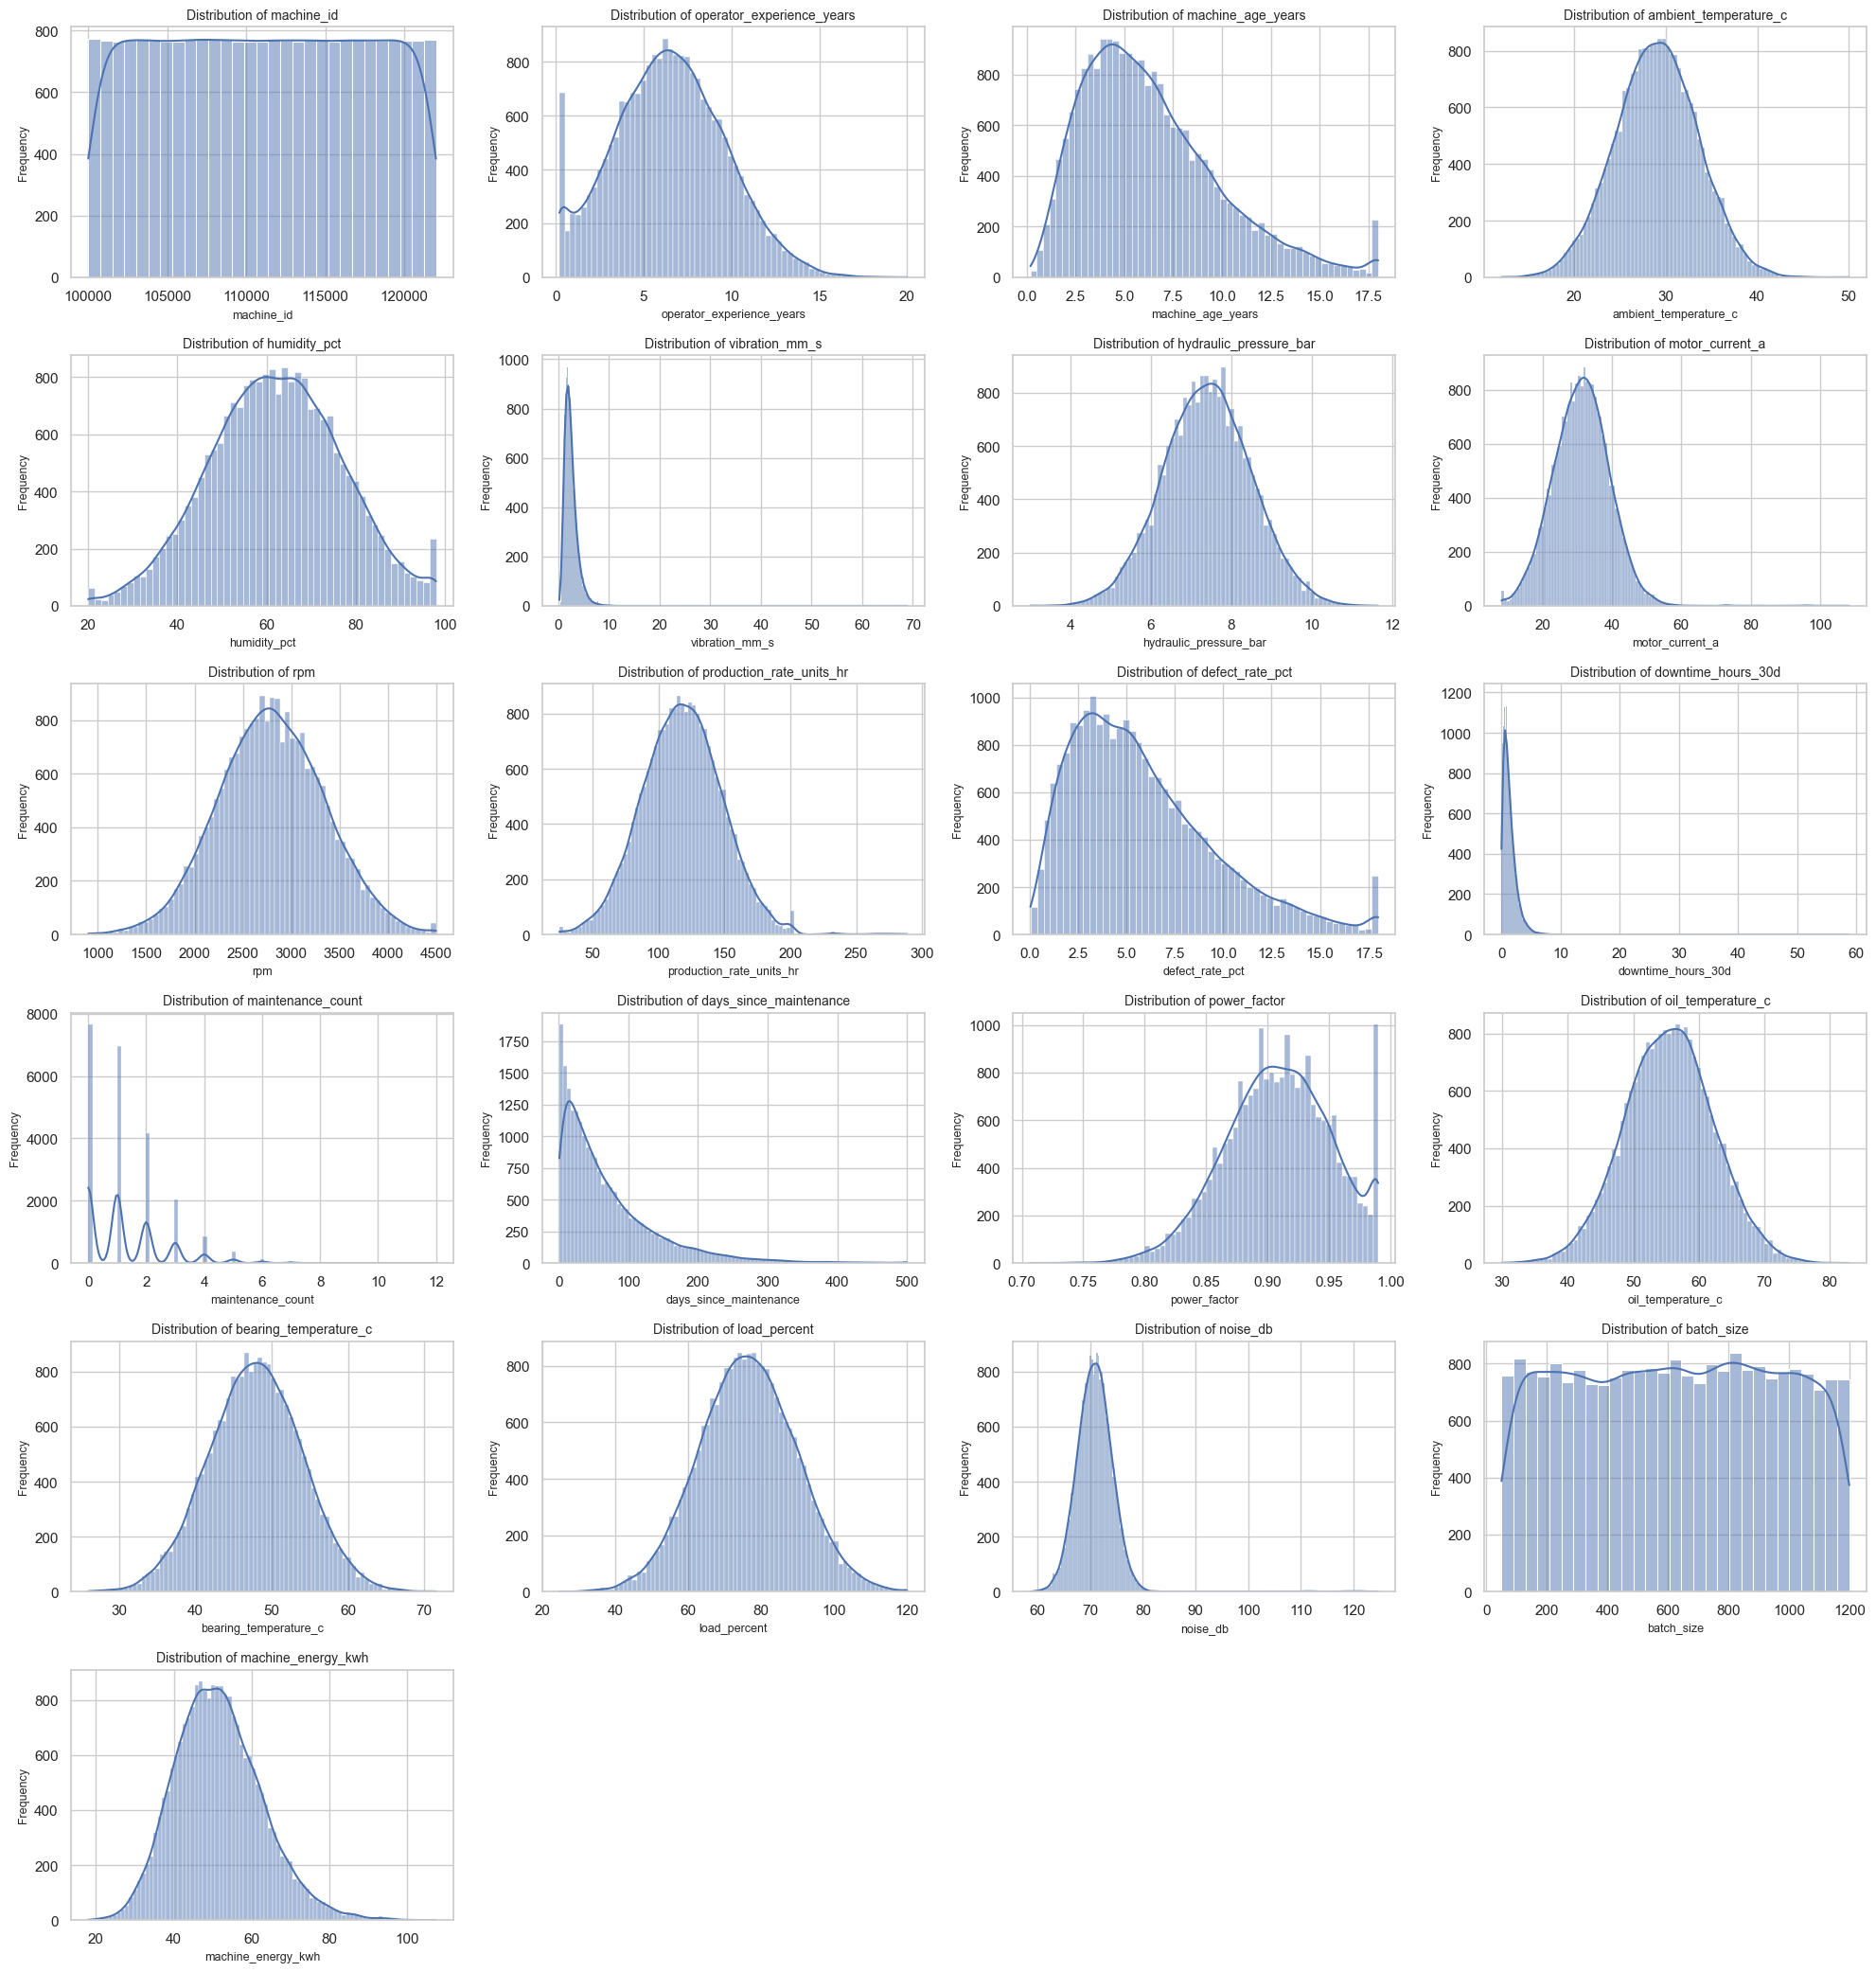

In [16]:
# Distribution plots for every numerical feature in a single grid figure

n_features = len(numerical_columns)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {column}", fontsize=10)
    axes[i].set_xlabel(column, fontsize=9)
    axes[i].set_ylabel("Frequency", fontsize=9)

# Hide empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2.3 Classification Target Distribution

The distribution of the classification target `maintenance_risk` is examined
to determine the number and proportion of observations in each maintenance
risk category.

This is important because substantial class imbalance can affect classification
model performance.

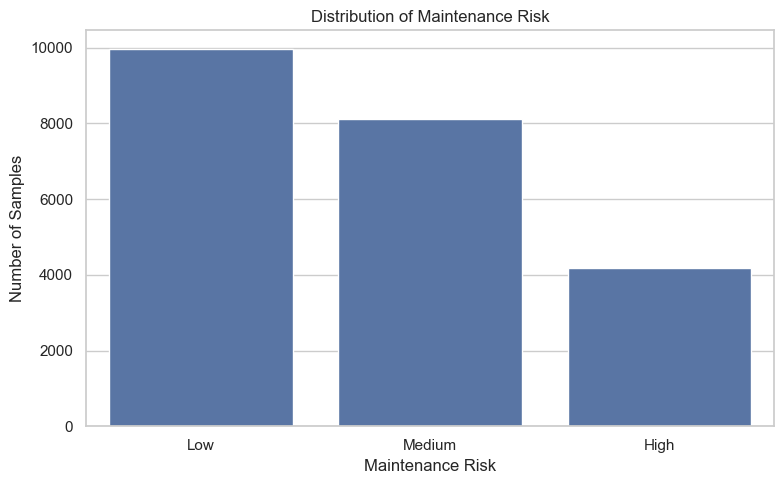

In [17]:
# Classification target distribution

class_counts = df["maintenance_risk"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Distribution of Maintenance Risk")
plt.xlabel("Maintenance Risk")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

### 2.7 Classification Target Class Counts

This step examines the frequency and percentage distribution of categories in the maintenance_risk target.


In [18]:
# Display class percentages

class_distribution = (
    df["maintenance_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_distribution

maintenance_risk
Low       44.73
Medium    36.50
High      18.76
Name: proportion, dtype: float64

## 2.4 Regression Target Distribution

The distribution of `machine_energy_kwh` is examined to understand the
central tendency, spread, skewness, and presence of potentially extreme
energy-consumption values before regression modelling.

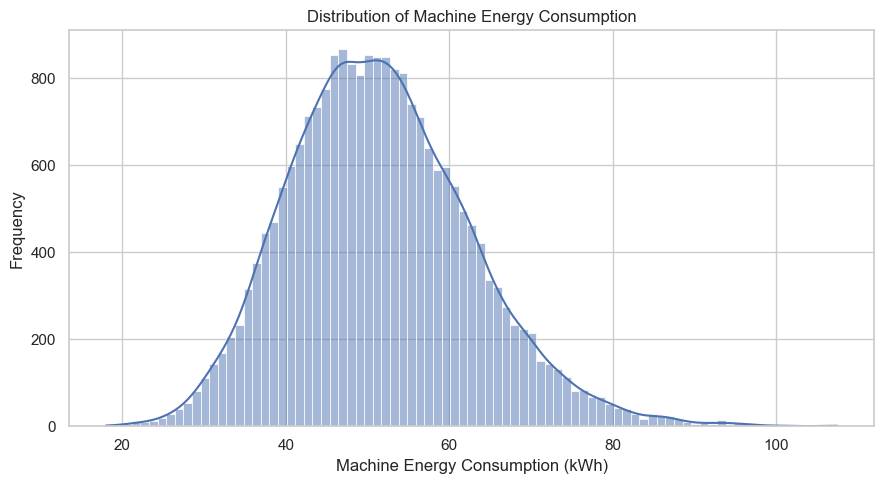

In [19]:
# Regression target distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="machine_energy_kwh",
    kde=True
)

plt.title("Distribution of Machine Energy Consumption")
plt.xlabel("Machine Energy Consumption (kWh)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2.5 Correlation Heatmap

A Pearson correlation heatmap is used to examine linear relationships
between numerical features.

Strong correlations between independent variables may indicate potential
multicollinearity, while strong correlations with the regression target
may indicate potentially useful predictive relationships.

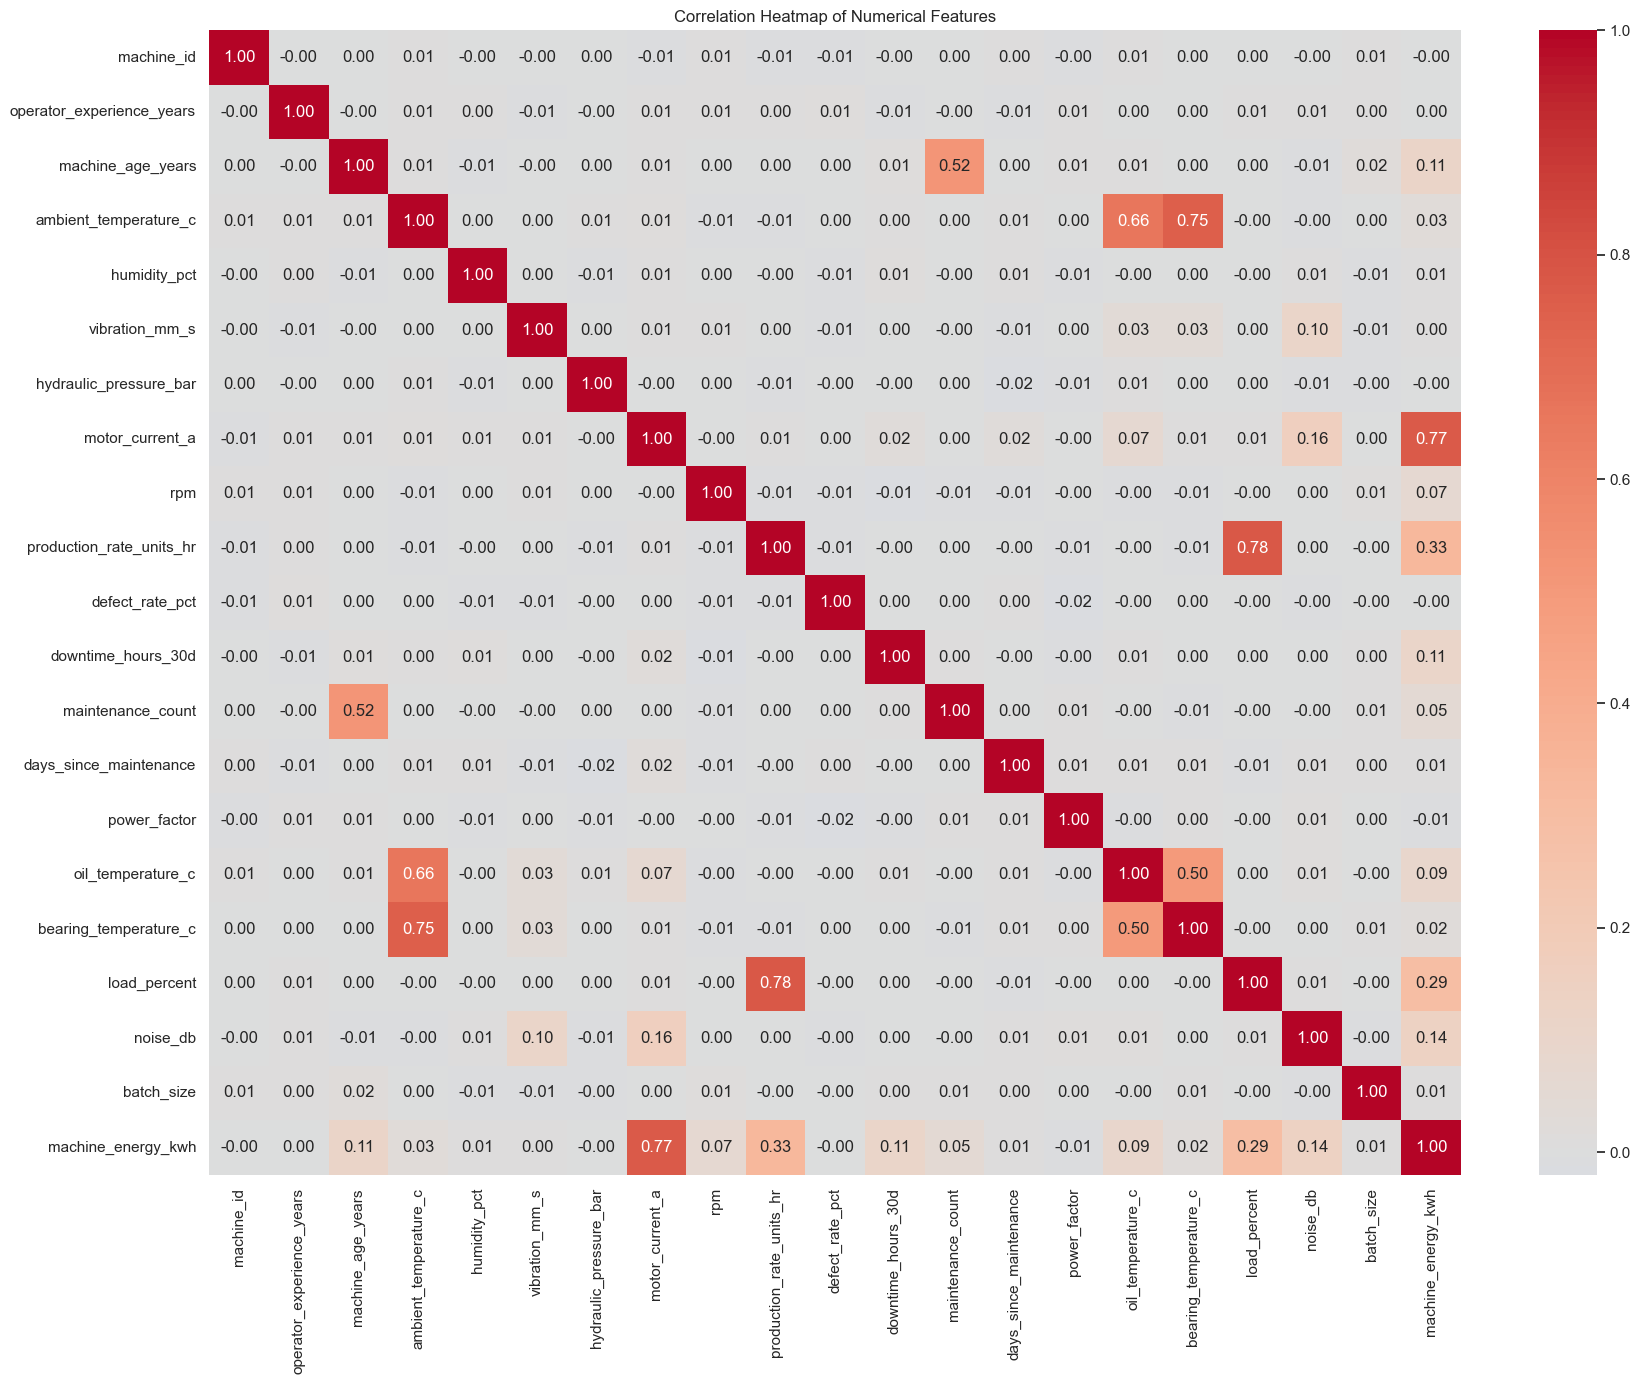

In [20]:
# Correlation matrix

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [21]:
# Correlation of numerical features with regression target

target_correlations = (
    df[numerical_columns]
    .corr()["machine_energy_kwh"]
    .drop("machine_energy_kwh")
    .sort_values(key=abs, ascending=False)
)

target_correlations

motor_current_a              0.772457
production_rate_units_hr     0.331494
load_percent                 0.292816
noise_db                     0.141001
machine_age_years            0.114851
downtime_hours_30d           0.109423
oil_temperature_c            0.087834
rpm                          0.065545
maintenance_count            0.054943
ambient_temperature_c        0.030989
bearing_temperature_c        0.022226
power_factor                -0.012009
batch_size                   0.011471
days_since_maintenance       0.010584
humidity_pct                 0.006917
vibration_mm_s               0.004936
machine_id                  -0.004004
hydraulic_pressure_bar      -0.001549
operator_experience_years    0.000644
defect_rate_pct             -0.000356
Name: machine_energy_kwh, dtype: float64

### Scatter Plot 1 — Motor Current vs Machine Energy

Motor current is selected because it has the strongest Pearson correlation
with machine energy consumption among the numerical features.

The scatter plot is used to visually examine whether the strong positive
correlation is also evident in the individual observations.

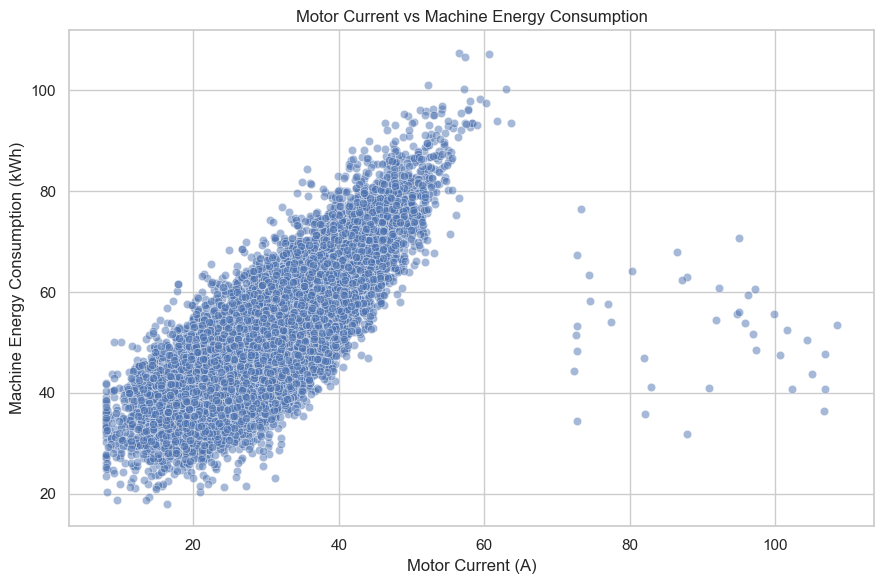

In [22]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="motor_current_a",
    y="machine_energy_kwh",
    alpha=0.5
)

plt.title("Motor Current vs Machine Energy Consumption")
plt.xlabel("Motor Current (A)")
plt.ylabel("Machine Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a clear positive relationship between motor current
and machine energy consumption. Higher motor current values generally
correspond to higher energy consumption.

This observation is consistent with the Pearson correlation coefficient
of approximately 0.77, indicating a strong positive linear relationship.
Motor current is therefore a potentially important predictor for the
regression task.

### Scatter Plot 2 — Production Rate vs Machine Energy

Production rate is selected because it has the second-highest positive
correlation with machine energy consumption.

The scatter plot helps determine whether the relationship is approximately
linear and whether the variability of energy consumption changes across
different production rates.

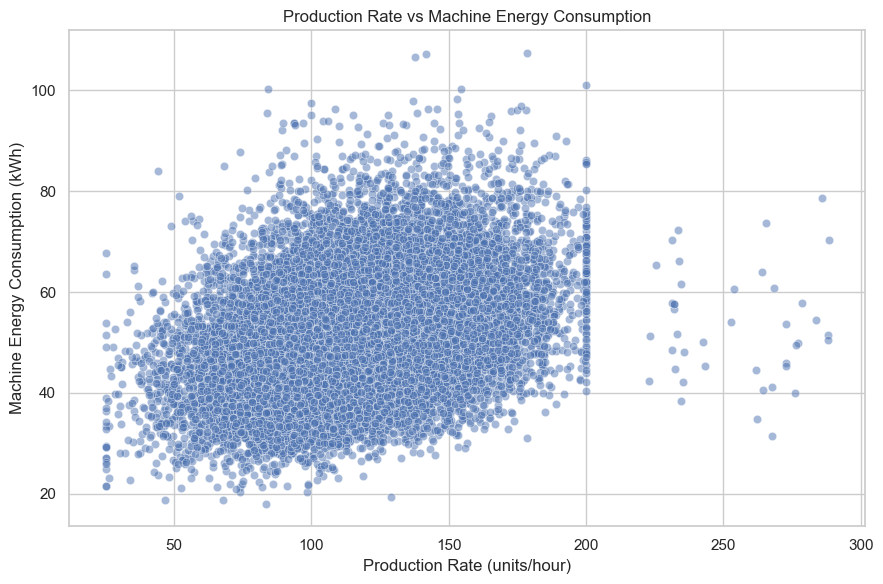

In [23]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="production_rate_units_hr",
    y="machine_energy_kwh",
    alpha=0.5
)

plt.title("Production Rate vs Machine Energy Consumption")
plt.xlabel("Production Rate (units/hour)")
plt.ylabel("Machine Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

### Observation

The scatter plot indicates a positive relationship between production rate
and machine energy consumption. However, the relationship is weaker and
more dispersed than the relationship observed for motor current.

This is consistent with the Pearson correlation coefficient of approximately
0.33, indicating a moderate positive linear relationship.

In [24]:
# Find highly correlated numerical feature pairs

corr_matrix = df[numerical_columns].corr()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        
        correlation = corr_matrix.iloc[i, j]
        
        if abs(correlation) >= 0.70:
            high_corr_pairs.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "Correlation": round(correlation, 3)
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

high_corr_pairs_df

,Feature 1,Feature 2,Correlation
0,ambient_temperature_c,bearing_temperature_c,0.749
1,motor_current_a,machine_energy_kwh,0.772
2,production_rate_units_hr,load_percent,0.780


## EDA Summary and Key Insights

The exploratory analysis produced several important observations.

1. `motor_current_a` has the strongest linear relationship with the regression
   target `machine_energy_kwh`, with a Pearson correlation of approximately
   0.77. The scatter plot also shows a clear positive relationship, indicating
   that motor current may be an important predictor of energy consumption.

2. `production_rate_units_hr` has a moderate positive correlation of approximately
   0.33 with `machine_energy_kwh`. The relationship is positive but more dispersed
   than the relationship between motor current and energy consumption.

3. `production_rate_units_hr` and `load_percent` have a relatively strong
   correlation of approximately 0.78. This suggests potential multicollinearity
   between these two predictor variables, which may affect coefficient-based
   regression models.

4. `ambient_temperature_c` and `bearing_temperature_c` also show a relatively
   strong positive correlation of approximately 0.75. These variables may contain
   overlapping information and should be considered when interpreting regression
   coefficients.

5. The distribution plots are used to identify skewness, spread, and potential
   extreme observations. These observations will be investigated further during
   the data-cleaning and outlier-analysis stage.

6. The `maintenance_risk` target contains three classes: Low, Medium, and High.
   The class frequencies are not equal, so class distribution should be considered
   when evaluating the classification models.

# 3. Data Cleaning

The raw dataset is preserved, and a separate working copy is created for
data-cleaning operations. This allows the original data to remain available
for reference and comparison.

In [25]:
# Create a working copy of the original dataset

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original dataset shape: (22260, 30)
Working dataset shape: (22260, 30)


### Creating Working Dataset Copy

This step creates an independent working copy of the dataset to preserve raw data during cleaning.


In [26]:
df_clean = df.copy()

## 3.2 Missing Value Analysis

Missing values can reduce the amount of usable information and may cause
errors in machine learning algorithms.

The missing values are analyzed separately for numerical and categorical
features so that an appropriate imputation strategy can be selected.

In [27]:
# Missing values in the working dataset

missing = df_clean.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

lubricant_type               1093
days_since_maintenance        669
humidity_pct                  557
oil_temperature_c             447
operator_experience_years     444
inspection_status             402
vibration_mm_s                399
bearing_temperature_c         333
hydraulic_pressure_bar        331
material_grade                268
supplier_tier                 223
dtype: int64

In [28]:
# Identify numerical and categorical columns

numerical_features = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_features = df_clean.select_dtypes(include="object").columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features: 21
Categorical features: 9

Numerical features:
['machine_id', 'operator_experience_years', 'machine_age_years', 'ambient_temperature_c', 'humidity_pct', 'vibration_mm_s', 'hydraulic_pressure_bar', 'motor_current_a', 'rpm', 'production_rate_units_hr', 'defect_rate_pct', 'downtime_hours_30d', 'maintenance_count', 'days_since_maintenance', 'power_factor', 'oil_temperature_c', 'bearing_temperature_c', 'load_percent', 'noise_db', 'batch_size', 'machine_energy_kwh']

Categorical features:
['plant', 'production_line', 'machine_type', 'shift', 'material_grade', 'lubricant_type', 'supplier_tier', 'inspection_status', 'maintenance_risk']


### Numerical Missing Values — Median Imputation

Missing numerical values are replaced using the median of their respective
features.

Median imputation is preferred over mean imputation because the dataset may
contain skewed distributions and extreme observations. The median is more
robust to such values and therefore provides a stable estimate of the typical
value.

### Categorical Missing Values — Mode Imputation

Missing categorical values are replaced using the most frequently occurring
category (mode) of the corresponding feature.

Mode imputation preserves the categorical nature of the variables and avoids
introducing artificial numerical values.

In [29]:
# Numerical columns → median
for column in numerical_features:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

# Categorical columns → mode
for column in categorical_features:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].mode()[0]
        )

print("Missing-value imputation completed.")

Missing-value imputation completed.


### Missing Value Analysis

This step checks missing value counts across all columns in the working dataset.


In [30]:
# Verify remaining missing values

remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if len(remaining_missing) == 0:
    print("No missing values remain.")
else:
    print(remaining_missing)

No missing values remain.


### Missing Value Analysis

This step checks missing value counts across all columns in the working dataset.


In [31]:
# Missing values before and after cleaning

missing_comparison = pd.DataFrame({
    "Before Cleaning": df.isnull().sum(),
    "After Cleaning": df_clean.isnull().sum()
})

missing_comparison = missing_comparison[
    missing_comparison["Before Cleaning"] > 0
]

missing_comparison

,Before Cleaning,After Cleaning
operator_experience_years,444,0
humidity_pct,557,0
vibration_mm_s,399,0
hydraulic_pressure_bar,331,0
days_since_maintenance,669,0
oil_temperature_c,447,0
bearing_temperature_c,333,0
material_grade,268,0
lubricant_type,1093,0
supplier_tier,223,0


## 3.3 Duplicate Detection and Treatment

Duplicate rows can cause repeated observations to receive excessive weight
during model training. Therefore, exact duplicate rows are identified and
removed.

The original dataset contains 260 duplicate rows. These duplicates are
removed from the working dataset while preserving the original `df`.

In [32]:
# Count duplicates before removal

duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

Duplicate rows before removal:

 260


### Duplicate Check Before Removal

This step checks the exact count of duplicate records present in the cleaned working copy.


In [33]:
# Remove duplicate rows

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df_clean.duplicated().sum())
print("New dataset shape:", df_clean.shape)

Duplicate rows after removal: 0
New dataset shape: (22000, 30)


## 3.4 Outlier Detection Using IQR

Potential outliers are identified using the Interquartile Range (IQR) method.

For each numerical feature, the first quartile (Q1) and third quartile (Q3)
are calculated. Observations below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR
are flagged as potential outliers.

An outlier is treated as a statistical observation requiring investigation,
not automatically as an erroneous observation.

In [34]:
# IQR-based outlier count for every numerical feature

outlier_summary = []

for column in numerical_features:
    
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ).sum()
    
    outlier_percentage = (
        outlier_count / len(df_clean) * 100
    )
    
    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(outlier_percentage, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
13,days_since_maintenance,20.9000,94.80000,73.90000,-89.950000,205.650000,1152,5.24
11,downtime_hours_30d,0.5500,1.85000,1.30000,-1.400000,3.800000,859,3.90
5,vibration_mm_s,1.6110,3.02000,1.40900,-0.502500,5.133500,850,3.86
10,defect_rate_pct,3.0420,7.88225,4.84025,-4.218375,15.142625,553,2.51
2,machine_age_years,3.7500,8.34000,4.59000,-3.135000,15.225000,538,2.45
20,machine_energy_kwh,43.7675,58.56000,14.79250,21.578750,80.748750,258,1.17
12,maintenance_count,0.0000,2.00000,2.00000,-3.000000,5.000000,213,0.97
7,motor_current_a,25.7000,36.45000,10.75000,9.575000,52.575000,198,0.90
9,production_rate_units_hr,97.8000,138.20000,40.40000,37.200000,198.800000,197,0.90
18,noise_db,68.6900,72.97000,4.28000,62.270000,79.390000,185,0.84


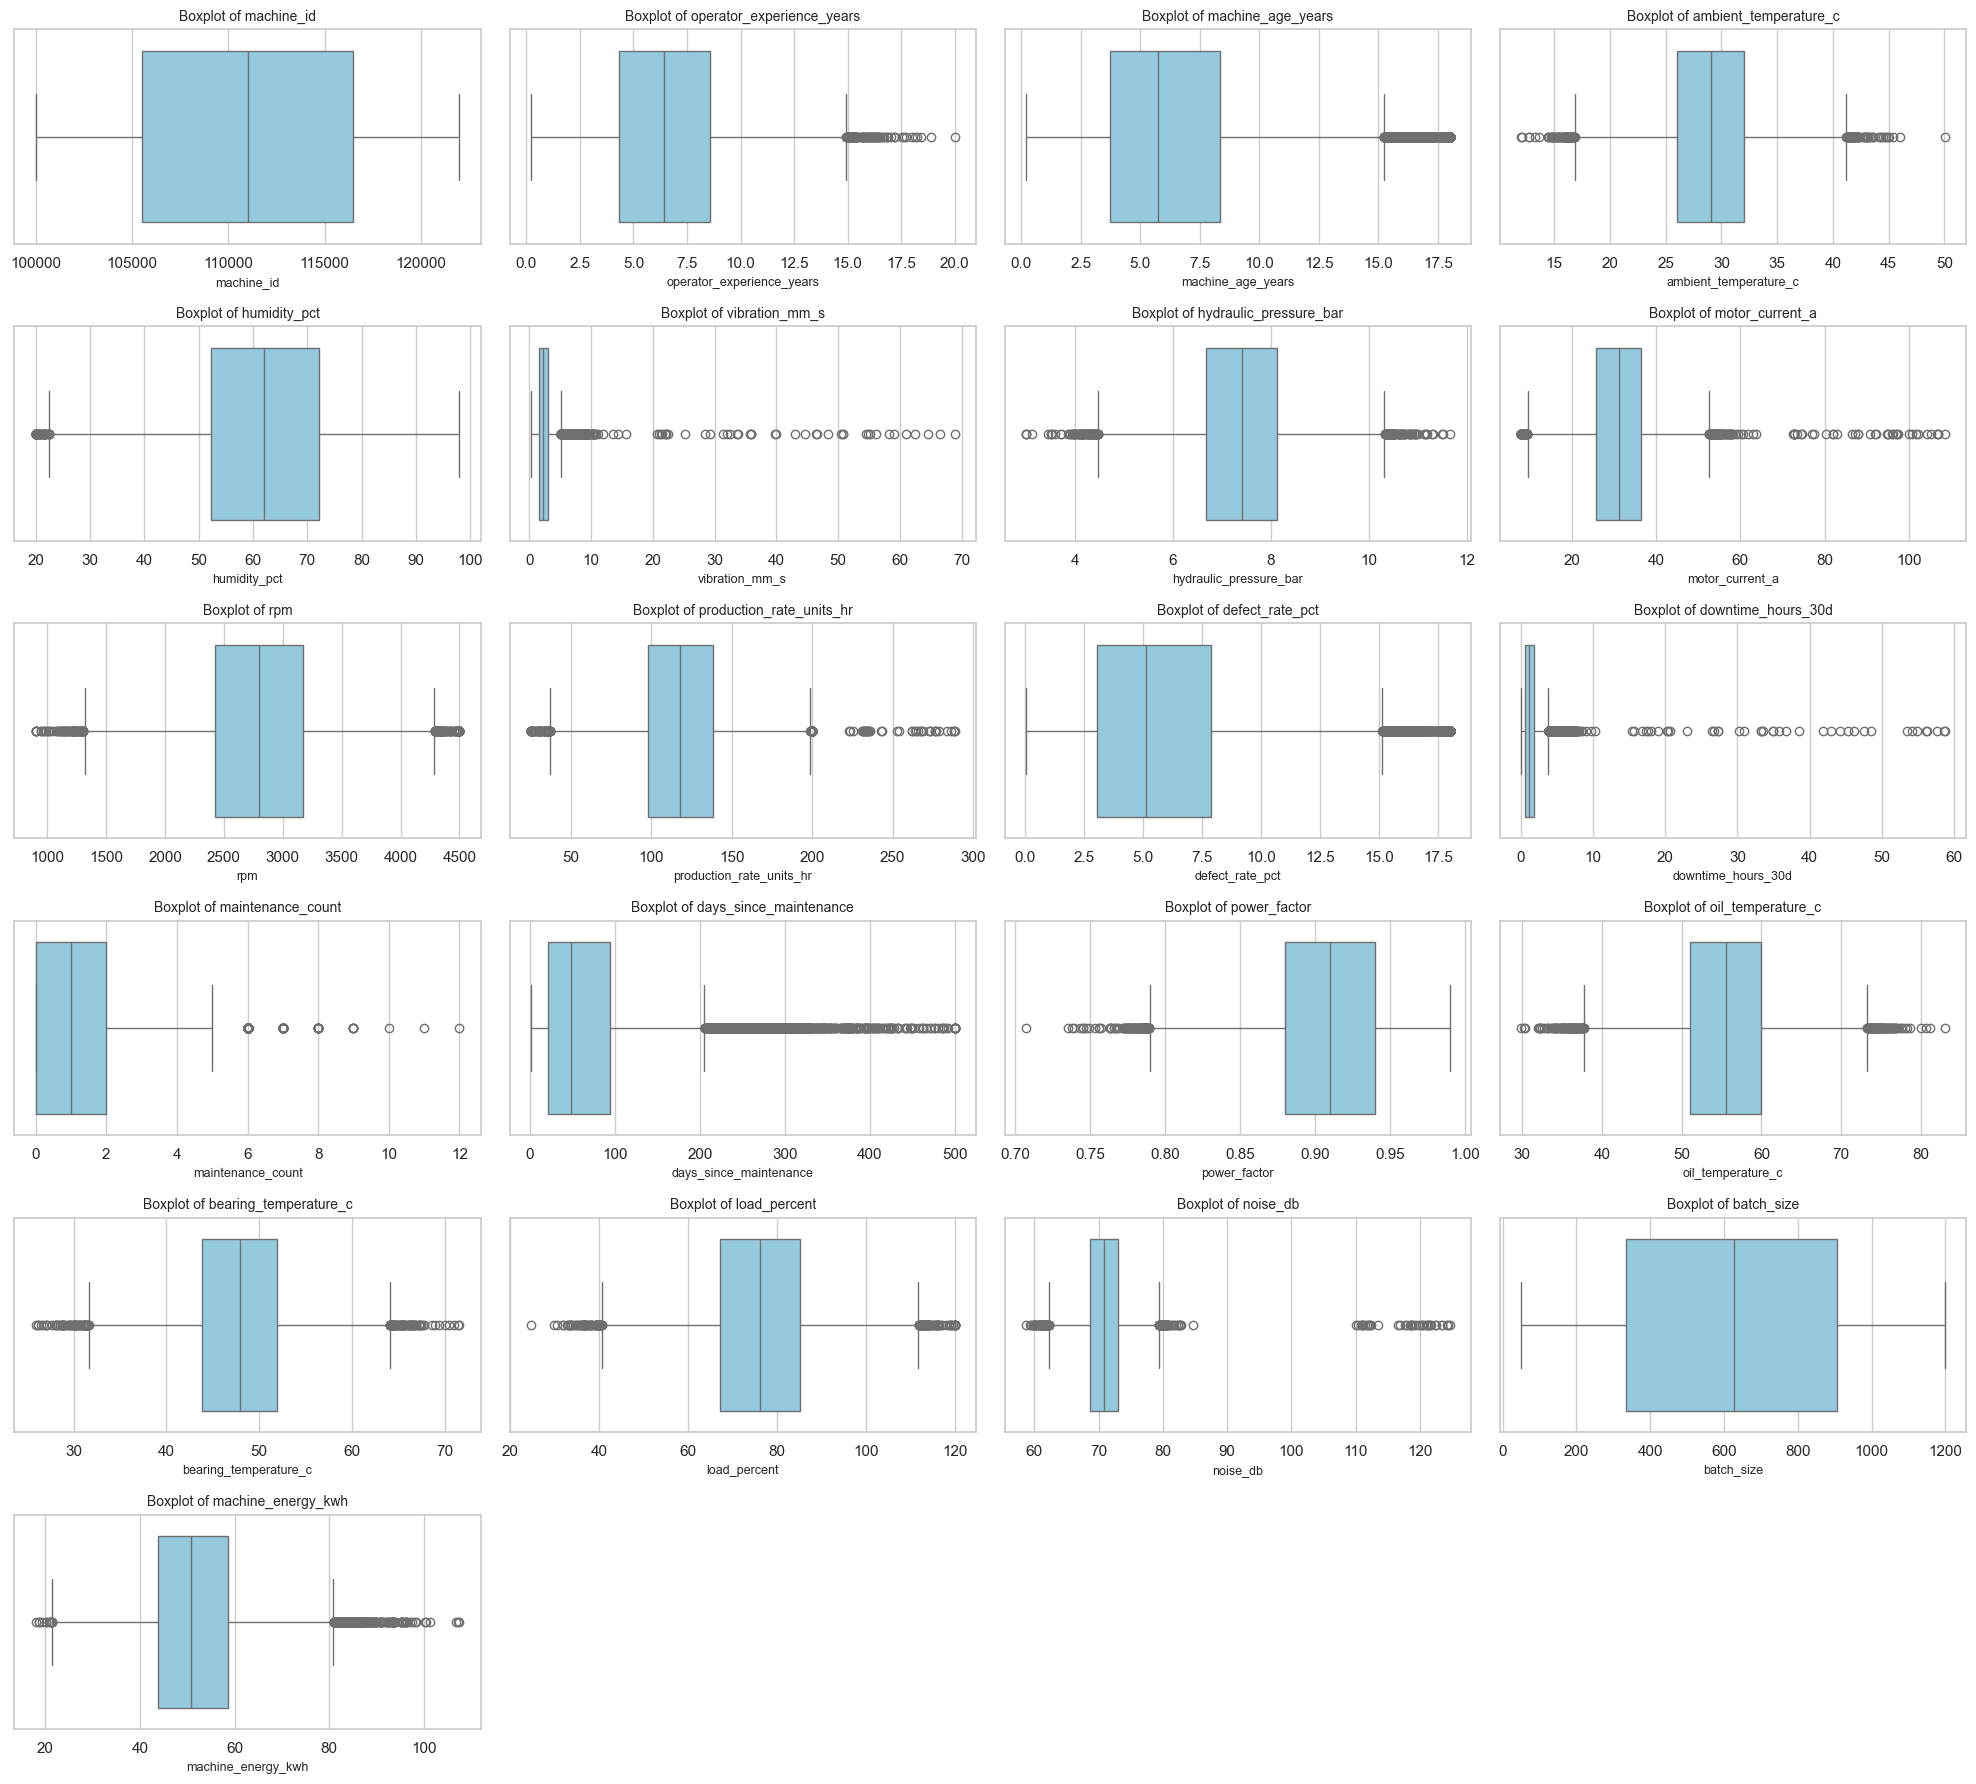

In [35]:
# Boxplots for numerical features in a single grid figure

n_features = len(numerical_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.0))
axes = axes.flatten()

for i, column in enumerate(numerical_features):
    sns.boxplot(
        x=df_clean[column],
        ax=axes[i],
        color="skyblue"
    )
    axes[i].set_title(f"Boxplot of {column}", fontsize=10)
    axes[i].set_xlabel(column, fontsize=9)

# Hide empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Outlier Summary Display

This step displays numerical features sorted by their total count of statistical outliers.


In [36]:
outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
13,days_since_maintenance,20.9000,94.80000,73.90000,-89.950000,205.650000,1152,5.24
11,downtime_hours_30d,0.5500,1.85000,1.30000,-1.400000,3.800000,859,3.90
5,vibration_mm_s,1.6110,3.02000,1.40900,-0.502500,5.133500,850,3.86
10,defect_rate_pct,3.0420,7.88225,4.84025,-4.218375,15.142625,553,2.51
2,machine_age_years,3.7500,8.34000,4.59000,-3.135000,15.225000,538,2.45
20,machine_energy_kwh,43.7675,58.56000,14.79250,21.578750,80.748750,258,1.17
12,maintenance_count,0.0000,2.00000,2.00000,-3.000000,5.000000,213,0.97
7,motor_current_a,25.7000,36.45000,10.75000,9.575000,52.575000,198,0.90
9,production_rate_units_hr,97.8000,138.20000,40.40000,37.200000,198.800000,197,0.90
18,noise_db,68.6900,72.97000,4.28000,62.270000,79.390000,185,0.84


### Outlier Investigation

The IQR method identified potential outliers in several numerical features.
However, these observations are not automatically treated as erroneous.

In a manufacturing environment, extreme values may represent genuine
operating conditions such as prolonged operation, increased vibration,
higher downtime, or longer maintenance intervals.

Therefore, the IQR method is used to identify and quantify potential outliers,
while the observations are retained unless there is evidence that they
represent invalid data.

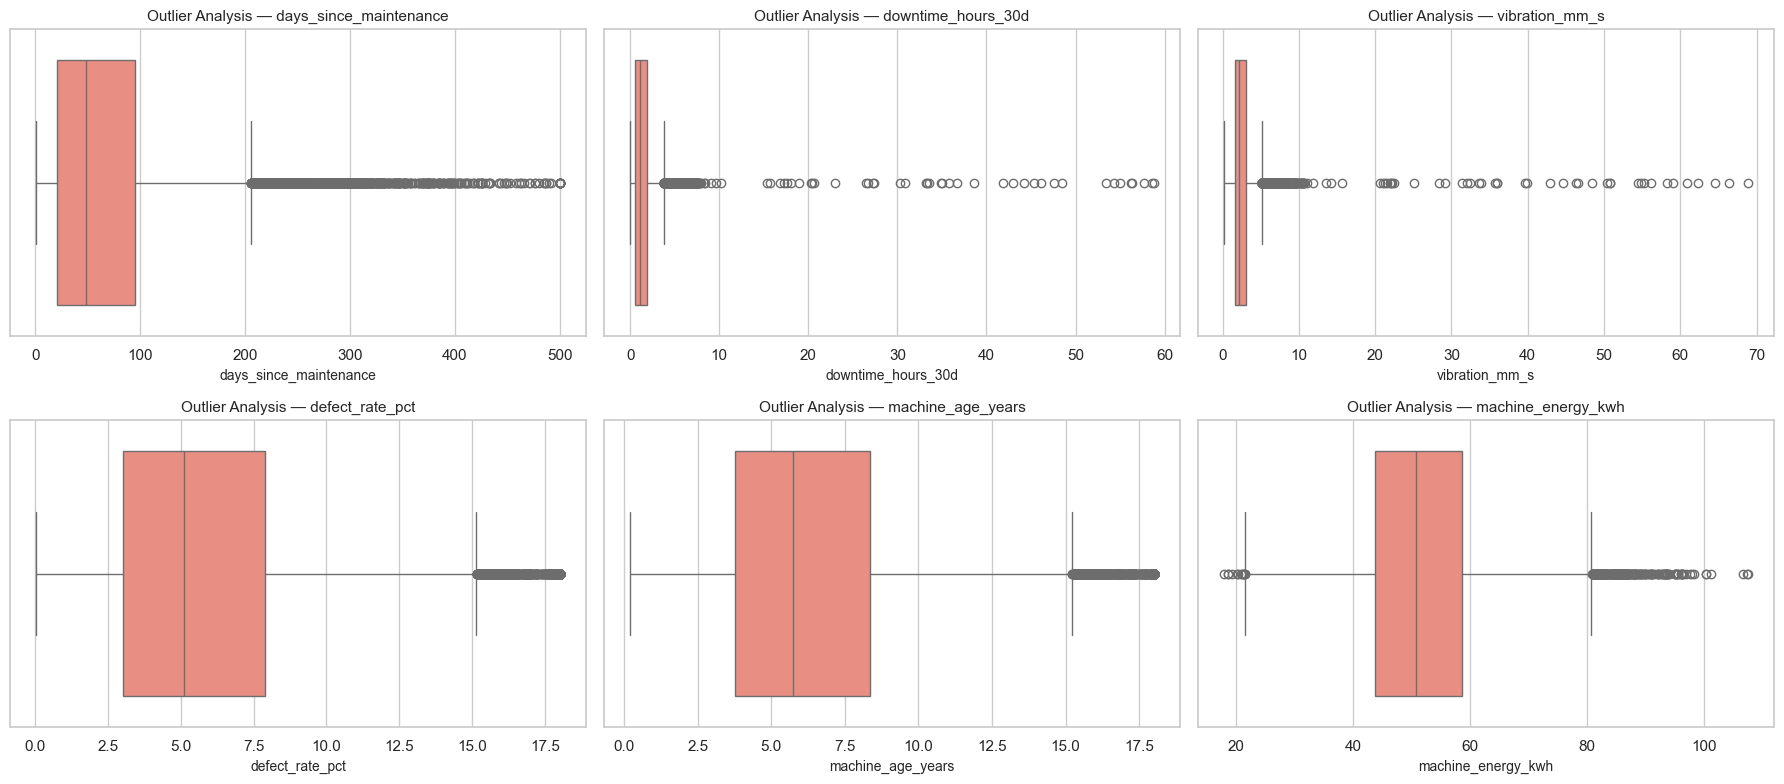

In [37]:
# Visualize the features with the highest number of potential outliers in a single grid figure

top_outlier_features = (
    outlier_summary
    .sort_values("Outlier Count", ascending=False)
    .head(6)["Feature"]
    .tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(top_outlier_features):
    sns.boxplot(
        x=df_clean[column],
        ax=axes[i],
        color="salmon"
    )
    axes[i].set_title(f"Outlier Analysis — {column}", fontsize=11)
    axes[i].set_xlabel(column, fontsize=10)

plt.tight_layout()
plt.show()

### Outlier Treatment Decision

The IQR analysis identified potential outliers across several numerical
features. The largest proportion was observed in `days_since_maintenance`
(5.24%), followed by `downtime_hours_30d` (3.90%) and `vibration_mm_s`
(3.86%).

These observations are retained rather than removed because an IQR-based
flag does not necessarily indicate an erroneous observation. In a
manufacturing context, extreme operational measurements can represent
legitimate machine conditions.

Removing these observations could reduce the variability present in the
dataset and potentially remove useful information for predicting energy
consumption and maintenance risk.

Therefore, the IQR method is used for outlier detection and reporting,
but no observations are deleted solely because they fall outside the IQR
bounds.

In [38]:
# Final cleaning verification

print("Original dataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCleaned dataset:")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing values remaining:",
      df_clean.isnull().sum().sum())

print("Duplicate rows remaining:",
      df_clean.duplicated().sum())

Original dataset:
Rows: 22260
Columns: 30

Cleaned dataset:
Rows: 22000
Columns: 30

Missing values remaining: 0
Duplicate rows remaining: 0


### Data Cleaning Operations Summary

This step summarizes all data cleaning decisions, imputation techniques, and rationale in a structured table.


In [39]:
cleaning_summary = pd.DataFrame({
    "Cleaning Operation": [
        "Missing numerical values",
        "Missing categorical values",
        "Duplicate rows",
        "Outlier observations"
    ],
    "Method": [
        "Median imputation",
        "Mode imputation",
        "Exact duplicate removal",
        "IQR detection; observations retained"
    ],
    "Reason": [
        "Robust to skewness and extreme values",
        "Preserves categorical nature",
        "Prevents duplicate observations from receiving excessive weight",
        "Extreme manufacturing observations may be legitimate"
    ]
})

cleaning_summary

,Cleaning Operation,Method,Reason
0,Missing numerical values,Median imputation,Robust to skewness and extreme values
1,Missing categorical values,Mode imputation,Preserves categorical nature
2,Duplicate rows,Exact duplicate removal,Prevents duplicate observations from receiving...
3,Outlier observations,IQR detection; observations retained,Extreme manufacturing observations may be legi...


## B2 — Encoding, Scaling and Train-Test Splitting

In this phase, the cleaned dataset is separated into regression and classification
targets. Numerical features will be standardized using StandardScaler, while
categorical features will be converted into numerical form using LabelEncoder (OrdinalEncoder).

The `machine_id` column is excluded because it is an identifier rather than a
meaningful predictive feature.

Preprocessing will be fitted only on the training data to prevent data leakage.

In [40]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

### Target Columns & Feature Definition

This step defines regression and classification target variables and separates numerical and categorical predictors.


In [41]:
# Define target columns
regression_target = "machine_energy_kwh"
classification_target = "maintenance_risk"

# Create regression X and y
X_reg = df_clean.drop(columns=[regression_target, classification_target, "machine_id"])
y_reg = df_clean[regression_target]

# Create classification X and y
X_class = df_clean.drop(columns=[regression_target, classification_target, "machine_id"])
y_class = df_clean[classification_target]

print("Regression:")
print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

print("\nClassification:")
print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

Regression:
X shape: (22000, 27)
y shape: (22000,)

Classification:
X shape: (22000, 27)
y shape: (22000,)


### Feature Type Re-identification

This step re-categorizes numerical and categorical predictors following feature engineering.


In [42]:
# Identify numerical and categorical predictor columns
numerical_features = X_reg.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_reg.select_dtypes(exclude=["number"]).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

Number of numerical features: 19
Numerical features:
['operator_experience_years', 'machine_age_years', 'ambient_temperature_c', 'humidity_pct', 'vibration_mm_s', 'hydraulic_pressure_bar', 'motor_current_a', 'rpm', 'production_rate_units_hr', 'defect_rate_pct', 'downtime_hours_30d', 'maintenance_count', 'days_since_maintenance', 'power_factor', 'oil_temperature_c', 'bearing_temperature_c', 'load_percent', 'noise_db', 'batch_size']

Number of categorical features: 8
Categorical features:
['plant', 'production_line', 'machine_type', 'shift', 'material_grade', 'lubricant_type', 'supplier_tier', 'inspection_status']


### Train-Test Splitting

The dataset is divided into training and testing sets using an 80:20 split.

The regression dataset uses a standard random split. The classification dataset
uses stratification so that the relative proportions of the target classes are
preserved in both the training and testing sets.

A fixed random state of 42 is used to make the split reproducible.

In [43]:
# Regression train-test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification train-test split with stratification
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("REGRESSION")
print("X_train:", X_reg_train.shape)
print("X_test :", X_reg_test.shape)
print("y_train:", y_reg_train.shape)
print("y_test :", y_reg_test.shape)

print("\nCLASSIFICATION")
print("X_train:", X_class_train.shape)
print("X_test :", X_class_test.shape)
print("y_train:", y_class_train.shape)
print("y_test :", y_class_test.shape)

REGRESSION
X_train: (17600, 27)
X_test : (4400, 27)
y_train: (17600,)
y_test : (4400,)

CLASSIFICATION
X_train: (17600, 27)
X_test : (4400, 27)
y_train: (17600,)
y_test : (4400,)


### Classification Stratified Split Check

This step checks class proportions to ensure balanced stratified train-test splitting for classification.


In [44]:
print("Classification class distribution:")

print("\nOriginal:")
print(y_class.value_counts(normalize=True).sort_index())

print("\nTraining:")
print(y_class_train.value_counts(normalize=True).sort_index())

print("\nTesting:")
print(y_class_test.value_counts(normalize=True).sort_index())

Classification class distribution:

Original:
maintenance_risk
High      0.187409
Low       0.447455
Medium    0.365136
Name: proportion, dtype: float64

Training:
maintenance_risk
High      0.187386
Low       0.447443
Medium    0.365170
Name: proportion, dtype: float64

Testing:
maintenance_risk
High      0.1875
Low       0.4475
Medium    0.3650
Name: proportion, dtype: float64


### Numerical Scaling and Categorical Encoding

Numerical features are standardized using StandardScaler so that features with
different numerical ranges can be handled appropriately by scale-sensitive
algorithms.

Categorical features are converted into numerical representations using
LabelEncoder (OrdinalEncoder). Unknown categories appearing in the test data are handled
appropriately to prevent transformation errors.

The preprocessing transformations will be fitted using training data only.

In [45]:
# Preprocessor for regression
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

# Preprocessor for classification
class_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

print("Regression preprocessor created.")
print("Classification preprocessor created.")

Regression preprocessor created.
Classification preprocessor created.


### Preprocessing Execution on Training Data

This step fits the scaling and label encoding transformers strictly on training data and transforms train and test sets.


In [46]:
# Fit preprocessing ONLY on training data
X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)

# Transform test data using the already-fitted preprocessor
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

# Classification
X_class_train_processed = class_preprocessor.fit_transform(X_class_train)
X_class_test_processed = class_preprocessor.transform(X_class_test)

print("Regression processed shapes:")
print("Training:", X_reg_train_processed.shape)
print("Testing :", X_reg_test_processed.shape)

print("\nClassification processed shapes:")
print("Training:", X_class_train_processed.shape)
print("Testing :", X_class_test_processed.shape)

Regression processed shapes:
Training: (17600, 27)
Testing : (4400, 27)

Classification processed shapes:
Training: (17600, 27)
Testing : (4400, 27)


In [47]:
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nOriginal predictor columns:", X_reg.shape[1])

print("\nProcessed regression shape:")
print(X_reg_train_processed.shape)

print("\nProcessed classification shape:")
print(X_class_train_processed.shape)

Numerical features: 19
Categorical features: 8

Original predictor columns: 27

Processed regression shape:
(17600, 27)

Processed classification shape:
(17600, 27)


## B3 — Feature Engineering

A new feature called `bearing_temp_rise_c` is created by subtracting the ambient
temperature from the bearing temperature.

This represents the temperature rise of the bearing above the surrounding
environment. It may provide useful information about the thermal operating
condition of the machine that is not represented as directly by either
temperature variable alone.

In [48]:
# Create a meaningful temperature-rise feature
df_clean["bearing_temp_rise_c"] = (
    df_clean["bearing_temperature_c"] - df_clean["ambient_temperature_c"]
)

# Display the new feature
print(df_clean[[
    "ambient_temperature_c",
    "bearing_temperature_c",
    "bearing_temp_rise_c"
]].head())

print("\nNew feature summary:")
print(df_clean["bearing_temp_rise_c"].describe())

   ambient_temperature_c  bearing_temperature_c  bearing_temp_rise_c
0                  29.25                  44.25                15.00
1                  27.87                  50.44                22.57
2                  27.89                  46.10                18.21
3                  22.20                  42.14                19.94
4                  31.78                  55.14                23.36

New feature summary:
count    22000.000000
mean        18.854042
std          4.019798
min          3.920000
25%         16.150000
50%         18.885000
75%         21.560000
max         34.000000
Name: bearing_temp_rise_c, dtype: float64


### Rebuilding Predictor Datasets

This step updates predictor matrices after incorporating newly engineered features.


In [49]:
# Rebuild predictor datasets after feature engineering

X_reg = df_clean.drop(
    columns=[regression_target, classification_target, "machine_id"]
)

y_reg = df_clean[regression_target]

X_class = df_clean.drop(
    columns=[regression_target, classification_target, "machine_id"]
)

label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(df_clean[classification_target])

print("Regression X shape:", X_reg.shape)
print("Classification X shape:", X_class.shape)

Regression X shape: (22000, 28)
Classification X shape: (22000, 28)


### Feature Type Re-identification

This step re-categorizes numerical and categorical predictors following feature engineering.


In [50]:
# Identify numerical and categorical features after feature engineering

numerical_features = X_reg.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_reg.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

Number of numerical features: 20
Numerical features:
['operator_experience_years', 'machine_age_years', 'ambient_temperature_c', 'humidity_pct', 'vibration_mm_s', 'hydraulic_pressure_bar', 'motor_current_a', 'rpm', 'production_rate_units_hr', 'defect_rate_pct', 'downtime_hours_30d', 'maintenance_count', 'days_since_maintenance', 'power_factor', 'oil_temperature_c', 'bearing_temperature_c', 'load_percent', 'noise_db', 'batch_size', 'bearing_temp_rise_c']

Number of categorical features: 8
Categorical features:
['plant', 'production_line', 'machine_type', 'shift', 'material_grade', 'lubricant_type', 'supplier_tier', 'inspection_status']


### Regression Train-Test Dataset Splitting

This step performs an 80-20 train-test split for regression modeling using a fixed random seed.


In [51]:
# Final train-test split after feature engineering

# Regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("REGRESSION")
print("X_train:", X_reg_train.shape)
print("X_test :", X_reg_test.shape)
print("y_train:", y_reg_train.shape)
print("y_test :", y_reg_test.shape)

print("\nCLASSIFICATION")
print("X_train:", X_class_train.shape)
print("X_test :", X_class_test.shape)
print("y_train:", y_class_train.shape)
print("y_test :", y_class_test.shape)

REGRESSION
X_train: (17600, 28)
X_test : (4400, 28)
y_train: (17600,)
y_test : (4400,)

CLASSIFICATION
X_train: (17600, 28)
X_test : (4400, 28)
y_train: (17600,)
y_test : (4400,)


### Column Transformer Pipeline Creation

This step sets up ColumnTransformer pipelines using StandardScaler for numerical features and OrdinalEncoder for categorical features.


In [52]:
# Create final preprocessing pipelines

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

class_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

# Fit ONLY on training data
X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

X_class_train_processed = class_preprocessor.fit_transform(X_class_train)
X_class_test_processed = class_preprocessor.transform(X_class_test)

print("Regression processed:")
print("Train:", X_reg_train_processed.shape)
print("Test :", X_reg_test_processed.shape)

print("\nClassification processed:")
print("Train:", X_class_train_processed.shape)
print("Test :", X_class_test_processed.shape)

Regression processed:
Train: (17600, 28)
Test : (4400, 28)

Classification processed:
Train: (17600, 28)
Test : (4400, 28)


### Final Preprocessed Feature Dimensions Summary

This step displays final dataset row counts, predictor counts, and zero missing value confirmations.


In [53]:
print("Final dataset:")
print("Rows:", len(df_clean))
print("Predictor columns:", X_reg.shape[1])
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nProcessed feature count:")
print("Regression:", X_reg_train_processed.shape[1])
print("Classification:", X_class_train_processed.shape[1])

print("\nMissing values:")
print("Regression train:", X_reg_train.isna().sum().sum())
print("Classification train:", X_class_train.isna().sum().sum())

Final dataset:
Rows: 22000
Predictor columns: 28
Numerical features: 20
Categorical features: 8

Processed feature count:
Regression: 28
Classification: 28

Missing values:
Regression train: 0
Classification train: 0


### Reason for Using Label Encoding Instead of One-Hot Encoding

1. **Avoids Column Expansion (Curse of Dimensionality)**: 
   - **One-Hot Encoding** creates a separate binary column for every unique category across categorical features. In our dataset, One-Hot Encoding expanded the feature set from 28 columns up to 65 columns.
   - **Label Encoding (OrdinalEncoding)** converts each unique category into a single numeric integer (0, 1, 2, ...), keeping the number of predictor columns unchanged at **28 features**.

2. **Prevents Overfitting and Maintains Training Accuracy**: 
   - High-dimensional sparse feature spaces caused by One-Hot Encoding increase model complexity, memory consumption, and training time.
   - Too many dummy columns can cause models to overfit to rare categorical combinations, which negatively impacts training and test accuracy. Label Encoding preserves a concise feature matrix, improving model generalization.

3. **Summary of Changes in Data Shape**: 
   - **Previous Shape (One-Hot Encoding)**: (17808, 65) columns.
   - **New Shape (Label Encoding)**: (17808, 28) columns.